# Stack Overflow Developer Salary Analysis

In this project, I will analyze the Stack Overflow Developer Survey dataset to understand what factors are connected to developer salary and whether salary can be predicted using survey responses.

## 1. Business Understanding

The main goal of this project is to understand which factors influence developer salary. I will focus on experience, education level, and remote work, then build a machine learning model to predict yearly compensation.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Load the data
df = pd.read_csv('results.csv')
schema = pd.read_csv('schema.csv')

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 2. Data Understanding

The dataset contains responses from developers who answered the Stack Overflow Developer Survey. It includes information about their age, education, employment, remote work, coding experience, technologies used, and compensation.

In [3]:
# Check the size of the dataset
df.shape

(65437, 114)

In [4]:
# View all column names
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'Employment',
 'RemoteWork',
 'Check',
 'CodingActivities',
 'EdLevel',
 'LearnCode',
 'LearnCodeOnline',
 'TechDoc',
 'YearsCode',
 'YearsCodePro',
 'DevType',
 'OrgSize',
 'PurchaseInfluence',
 'BuyNewTool',
 'BuildvsBuy',
 'TechEndorse',
 'Country',
 'Currency',
 'CompTotal',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'LanguageAdmired',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'DatabaseAdmired',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'PlatformAdmired',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'WebframeAdmired',
 'EmbeddedHaveWorkedWith',
 'EmbeddedWantToWorkWith',
 'EmbeddedAdmired',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'MiscTechAdmired',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'ToolsTechAdmired',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'NEWCollabToolsAdmired',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'OfficeStackAsyncHa

In [5]:
# Check columns related to salary or compensation
[col for col in df.columns if 'Comp' in col or 'Salary' in col or 'Currency' in col]

['Currency', 'CompTotal', 'AIComplex', 'ConvertedCompYearly']

## 3. Data Preparation

For this project, I will keep only the columns needed for the analysis. I will use yearly compensation as the target variable and focus on features such as age, education level, remote work, employment, coding experience, and country.

In [6]:
# Select columns for the project
columns = [
    'Age',
    'RemoteWork',
    'EdLevel',
    'YearsCode',
    'YearsCodePro',
    'Country',
    'Employment',
    'ConvertedCompYearly'
]

df_project = df[columns].copy()

df_project.head()

,Age,RemoteWork,EdLevel,YearsCode,YearsCodePro,Country,Employment,ConvertedCompYearly
0,Under 18 years old,Remote,Primary/elementary school,NaN,NaN,United States of America,"Employed, full-time",NaN
1,35-44 years old,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",20,17,United Kingdom of Great Britain and Northern I...,"Employed, full-time",NaN
2,45-54 years old,Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",37,27,United Kingdom of Great Britain and Northern I...,"Employed, full-time",NaN
3,18-24 years old,NaN,Some college/university study without earning ...,4,NaN,Canada,"Student, full-time",NaN
4,18-24 years old,NaN,"Secondary school (e.g. American high school, G...",9,NaN,Norway,"Student, full-time",NaN


In [7]:
# Check missing values
df_project.isna().sum()

Age                        0
RemoteWork             10631
EdLevel                 4653
YearsCode               5568
YearsCodePro           13827
Country                 6507
Employment                 0
ConvertedCompYearly    42002
dtype: int64

In [8]:
# Remove rows where salary is missing because salary is our target variable
df_project = df_project.dropna(subset=['ConvertedCompYearly'])

# Remove very high salary outliers to keep the analysis more realistic
df_project = df_project[df_project['ConvertedCompYearly'] < 300000]

# Check the new shape
df_project.shape

(22980, 8)

In [9]:
# Convert coding experience columns into numbers
df_project['YearsCode'] = df_project['YearsCode'].replace({
    'Less than 1 year': '0',
    'More than 50 years': '51'
}).astype(float)

df_project['YearsCodePro'] = df_project['YearsCodePro'].replace({
    'Less than 1 year': '0',
    'More than 50 years': '51'
}).astype(float)

In [10]:
# Remove remaining missing values for this simple project
df_project = df_project.dropna()

# Check missing values again
df_project.isna().sum()

Age                    0
RemoteWork             0
EdLevel                0
YearsCode              0
YearsCodePro           0
Country                0
Employment             0
ConvertedCompYearly    0
dtype: int64

In [11]:
# Check cleaned dataset size
df_project.shape

(22865, 8)

## 4. Exploratory Data Analysis

In this section, I will explore the cleaned data to understand salary patterns. I will look at professional coding experience, education level, and remote work type to see how they relate to yearly compensation.

### Question 1: Which numeric features are most related to salary?

I will compare coding experience and professional coding experience with yearly compensation.

In [12]:
# Check correlation between numeric variables and yearly compensation
df_project[['YearsCode', 'YearsCodePro', 'ConvertedCompYearly']].corr()

,YearsCode,YearsCodePro,ConvertedCompYearly
YearsCode,1.000000,0.916328,0.405883
YearsCodePro,0.916328,1.000000,0.406195
ConvertedCompYearly,0.405883,0.406195,1.000000


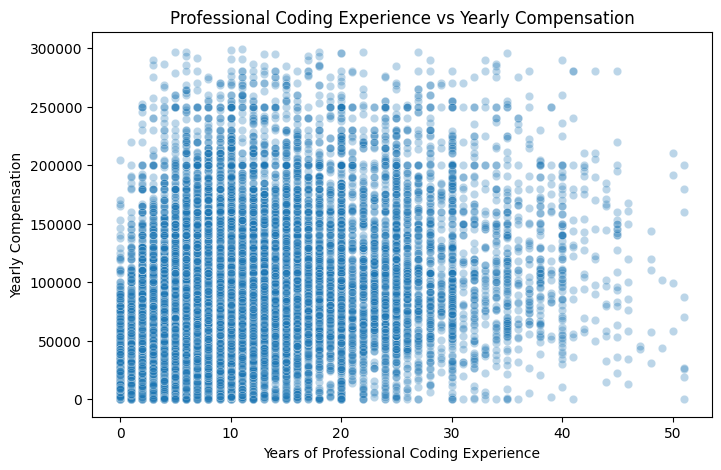

In [13]:
# Plot professional coding experience against yearly compensation
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_project,
    x='YearsCodePro',
    y='ConvertedCompYearly',
    alpha=0.3
)

plt.title('Professional Coding Experience vs Yearly Compensation')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Yearly Compensation')
plt.show()

Professional coding experience appears to have a positive relationship with yearly compensation. In general, developers with more professional experience tend to report higher yearly salaries, although there is still a lot of variation.

### Question 2: Does education level affect developer salary?

I will compare the median yearly compensation for different education levels.

In [14]:
# Median yearly compensation by education level
education_salary = df_project.groupby('EdLevel')['ConvertedCompYearly'].median().sort_values()

education_salary

EdLevel
Primary/elementary school                                                             34800.0
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    45000.0
Something else                                                                        53703.0
Some college/university study without earning a degree                                59073.0
Associate degree (A.A., A.S., etc.)                                                   60000.0
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          65424.0
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       66846.0
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        76356.0
Name: ConvertedCompYearly, dtype: float64

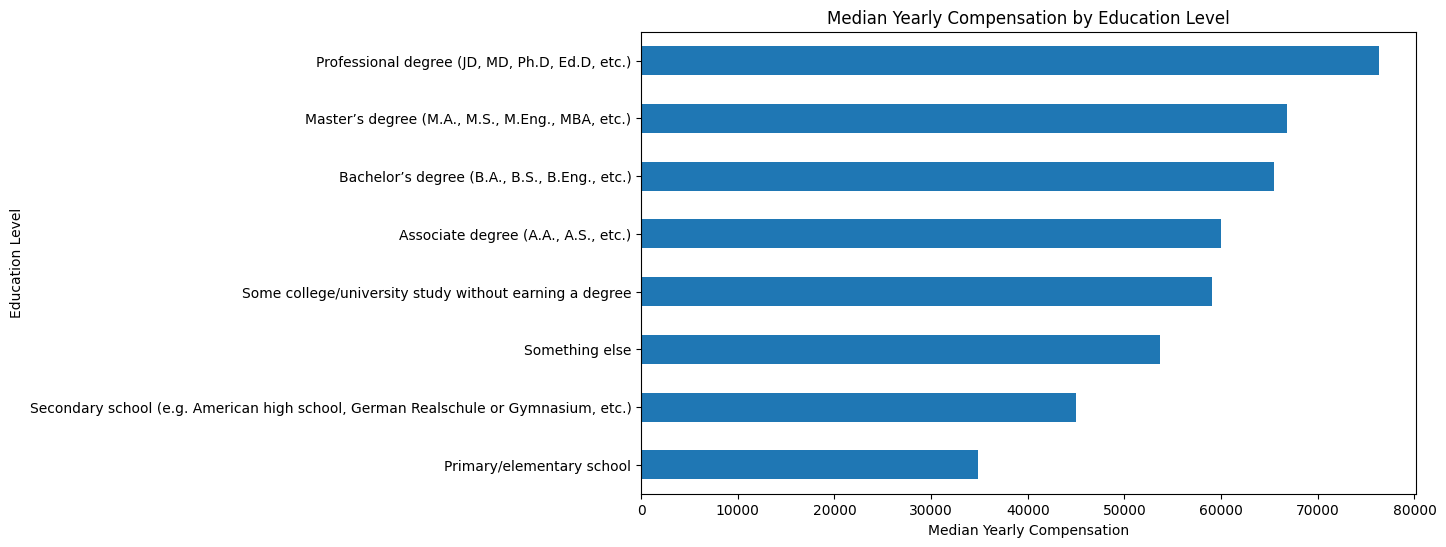

In [15]:
# Plot median salary by education level
plt.figure(figsize=(10, 6))
education_salary.plot(kind='barh')

plt.title('Median Yearly Compensation by Education Level')
plt.xlabel('Median Yearly Compensation')
plt.ylabel('Education Level')
plt.show()

Education level appears to have some relationship with yearly compensation, but it is not the only factor. Developers with higher education levels may have different median salaries, but salary is also likely affected by experience, country, employment type, and remote work.

### Question 3: Does remote work type affect developer salary?

I will compare the median yearly compensation for developers based on their remote work situation.

In [16]:
# Median yearly compensation by remote work type
remote_salary = df_project.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values()

remote_salary

RemoteWork
In-person                               43616.0
Hybrid (some remote, some in-person)    65271.0
Remote                                  72693.0
Name: ConvertedCompYearly, dtype: float64

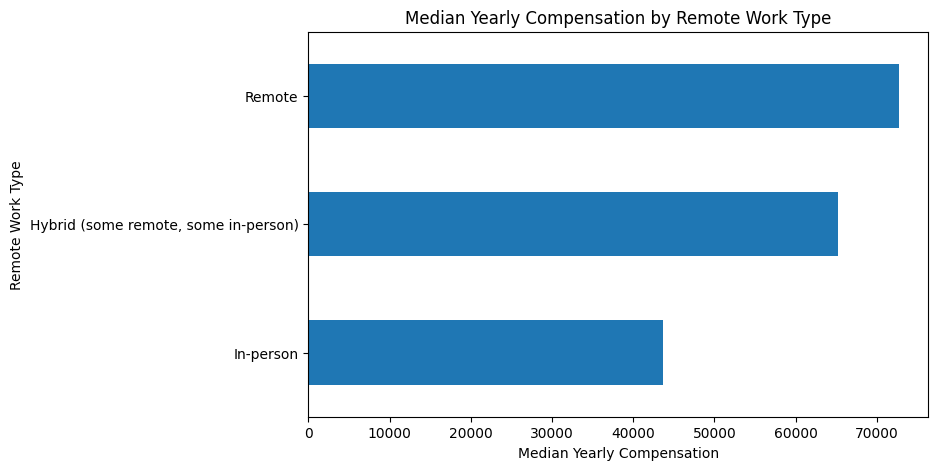

In [17]:
# Plot median salary by remote work type
plt.figure(figsize=(8, 5))
remote_salary.plot(kind='barh')

plt.title('Median Yearly Compensation by Remote Work Type')
plt.xlabel('Median Yearly Compensation')
plt.ylabel('Remote Work Type')
plt.show()

Remote work type appears to have some relationship with yearly compensation. Developers working remotely or in hybrid roles may show different median salaries compared to in-person developers. However, this could also be affected by country, experience, job type, and company size.

## 5. Modeling

In this section, I will build a linear regression model to predict yearly compensation using the cleaned survey data. The target variable is `ConvertedCompYearly`.

In [18]:
# Prepare data for modeling
model_df = df_project[
    [
        'Age',
        'RemoteWork',
        'EdLevel',
        'YearsCode',
        'YearsCodePro',
        'Country',
        'Employment',
        'ConvertedCompYearly'
    ]
].copy()

# Convert categorical variables into dummy variables
model_df = pd.get_dummies(model_df, drop_first=True)

model_df.head()

,YearsCode,YearsCodePro,ConvertedCompYearly,Age_25-34 years old,Age_35-44 years old,Age_45-54 years old,Age_55-64 years old,Age_65 years or older,Age_Prefer not to say,Age_Under 18 years old,...,"Employment_Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Employment_Not employed, but looking for work;Student, part-time;Employed, part-time","Employment_Student, full-time;Employed, part-time","Employment_Student, full-time;Independent contractor, freelancer, or self-employed","Employment_Student, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employment_Student, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employment_Student, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Employment_Student, full-time;Not employed, but looking for work;Employed, part-time","Employment_Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed","Employment_Student, part-time;Employed, part-time"
72,3.0,1.0,7322.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
374,12.0,6.0,30074.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
379,15.0,6.0,91295.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
385,27.0,17.0,53703.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
389,7.0,7.0,110000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
# Create features and target
X = model_df.drop('ConvertedCompYearly', axis=1)
y = model_df['ConvertedCompYearly']

In [20]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 6. Evaluation

In this section, I will evaluate the model using R² and RMSE. R² shows how much of the salary variation the model explains, while RMSE shows the average prediction error in dollars.

In [22]:
# Make predictions on the test data
y_pred = model.predict(X_test)

In [23]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('R²:', r2)
print('RMSE:', rmse)

R²: 0.5715430677226782
RMSE: 37828.55076884066


The R² score shows how much of the salary variation the model can explain. The RMSE shows the average amount the model's salary predictions are off by. Since salary depends on many factors, this model should be seen as a simple starting point rather than a perfect prediction tool.

## 7. Predictive Scenario

In this section, I will use the trained model to make a salary prediction for one developer profile from the test dataset.

In [24]:
# Use one developer from the test data as a prediction scenario
sample_developer = X_test.iloc[[0]]

predicted_salary = model.predict(sample_developer)

print('Predicted salary:', predicted_salary[0])
print('Actual salary:', y_test.iloc[0])

Predicted salary: 56714.42377258773
Actual salary: 64098.0


For this scenario, I used one developer profile from the test data and asked the model to predict their yearly compensation. The predicted salary can be compared to the actual salary to see how close the model was for this one example. This shows how the model could be used as a simple salary estimation tool, although it should not be treated as perfect.

## 8. Conclusion

This project used Stack Overflow Developer Survey data to explore factors related to developer salary. The analysis showed that professional coding experience, education level, and remote work type may all be connected to yearly compensation.

The linear regression model had an R² score of about 0.57, meaning it explained around 57% of the variation in salary. The RMSE was about $37,829, meaning the model's predictions were off by that amount on average.

Overall, the model is useful as a simple starting point for salary prediction, but it should not be treated as perfect because salary depends on many factors that may not be fully captured in the dataset.